# Project: Laptop Price Predictor
**Machine Learning Assignment**

Submitted by: Md. Shafiqul Islam; ID: 905253024; Batch: 9th

Submission Date: May 14, 2026

## 1. Import Libraries

In [37]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA

from sklearn.model_selection import train_test_split, cross_val_score

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

import warnings
warnings.filterwarnings('ignore')

print('All libraries imported successfully!')

All libraries imported successfully!


## 2. Data Loading

In [38]:
df = pd.read_csv('Cleaned_Laptop_data.csv')
print(f'Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns')
df.head()

Dataset loaded: 845 rows, 18 columns


,brand,model,processor_brand,processor_Name,processor_gnrtn,ram_gb,Apps,ssd,hdd,os,os_bit,graphic_card_gb,weight,display_size,warranty,Touchscreen,msoffice,Price
0,ASUS,Celeron,Intel,5,Missing,4.0,Cooling,0,1024,Windows,64,0,Casual,15.6,1,No,No,23990.0
1,ASUS,VivoBook,Intel,5,10th,4.0,DDR3,512,0,Windows,64,0,Casual,15.6,1,No,No,37990.0
2,ASUS,Vivobook,Intel,A6-9225 Processor,10th,4.0,DDR3,0,1024,Windows,64,0,Casual,14.1,1,No,No,NaN
3,HP,Core,Intel,APU Dual,11th,4.0,DDR3,512,0,Windows,64,0,ThinNlight,15.6,1,No,Yes,54990.0
4,HP,Core,Intel,APU Dual,11th,4.0,DDR3,512,0,Windows,64,0,ThinNlight,15.6,0,No,No,54990.0


In [39]:
df.tail()

,brand,model,processor_brand,processor_Name,processor_gnrtn,ram_gb,Apps,ssd,hdd,os,os_bit,graphic_card_gb,weight,display_size,warranty,Touchscreen,msoffice,Price
840,DELL,Inspiron,AMD,Ryzen 9,Missing,16.0,Unified,512,0,Windows,64,0,ThinNlight,15.6,0,No,No,42090.0
841,HP,Pavilion,AMD,Ryzen 9,Missing,16.0,Unified,512,0,Windows,64,4,Gaming,15.6,1,No,Yes,64990.0
842,ASUS,EeeBook,Intel,Ryzen 9,Missing,16.0,Unified,0,0,Windows,64,0,Casual,0,0,No,No,22990.0
843,HP,Pavilion,AMD,Slot for,Missing,16.0,Unified,512,0,Windows,64,2,Casual,14,1,No,Yes,79990.0
844,Lenovo,Ideapad,Intel,Snapdragon 7c,10th,16.0,Unified,512,0,Windows,64,2,Casual,14,1,Yes,Yes,86999.0


## 3. Feature Extraction

In [40]:
# Extract the numeric generation number as a new feature.
df['processor_gnrtn_num'] = df['processor_gnrtn'].str.extract(r'(\d+)').astype(float)

# Conditional Imputation
df['processor_gnrtn_num'] = df.groupby('processor_Name')['processor_gnrtn_num'].transform(
    lambda x: x.fillna(x.mode()[0] if not x.mode().empty else df['processor_gnrtn_num'].mode()[0])
)

# Storage Feature Engineering
df['total_storage'] = df['ssd'] + df['hdd']
df['is_ssd_only'] = ((df['ssd'] > 0) & (df['hdd'] == 0)).astype(int)

# Performance Density Ratios
df['display_size'] = pd.to_numeric(df['display_size'], errors='coerce')
df['display_size'] = df['display_size'].replace(0, np.nan)

df['ram_per_inch'] = df.apply(
    lambda row: row['ram_gb'] / row['display_size'] if row['display_size'] > 0 else 0, 
    axis=1
)

# Hardware Classification Flags
df['has_dedicated_gpu'] = (df['graphic_card_gb'] > 0).astype(int)
df['is_compact_screen'] = (df['display_size'] < 14.0).astype(int)

# Preview the newly extracted features
new_features = ['total_storage', 'is_ssd_only', 'ram_per_inch', 'has_dedicated_gpu', 'is_compact_screen', 'processor_gnrtn_num']

df[new_features].head()

,total_storage,is_ssd_only,ram_per_inch,has_dedicated_gpu,is_compact_screen,processor_gnrtn_num
0,1024,0,0.256410,0,0,10.0
1,512,1,0.256410,0,0,10.0
2,1024,0,0.283688,0,0,10.0
3,512,1,0.256410,0,0,11.0
4,512,1,0.256410,0,0,11.0


## 4. Data Info

In [41]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 845 entries, 0 to 844
Data columns (total 24 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   brand                845 non-null    str    
 1   model                845 non-null    str    
 2   processor_brand      845 non-null    str    
 3   processor_Name       845 non-null    str    
 4   processor_gnrtn      845 non-null    str    
 5   ram_gb               845 non-null    float64
 6   Apps                 845 non-null    str    
 7   ssd                  845 non-null    int64  
 8   hdd                  845 non-null    int64  
 9   os                   845 non-null    str    
 10  os_bit               845 non-null    int64  
 11  graphic_card_gb      845 non-null    int64  
 12  weight               845 non-null    str    
 13  display_size         784 non-null    float64
 14  warranty             845 non-null    int64  
 15  Touchscreen          845 non-null    str    
 16  m

In [42]:
df.describe()

,ram_gb,ssd,hdd,os_bit,graphic_card_gb,display_size,warranty,Price,processor_gnrtn_num,total_storage,is_ssd_only,ram_per_inch,has_dedicated_gpu,is_compact_screen
count,845.000000,845.000000,845.000000,845.000000,845.000000,784.000000,845.000000,842.000000,845.000000,845.000000,845.000000,845.000000,845.000000,845.000000
mean,9.773491,444.478107,175.715976,59.342012,1.230769,14.762041,0.707692,77355.592637,10.622485,620.194083,0.756213,0.613403,0.301775,0.118343
std,4.107819,315.168771,385.502878,11.292018,2.079008,0.982855,0.606833,47077.041740,0.789874,375.419614,0.429620,0.326444,0.459300,0.323205
min,4.000000,0.000000,0.000000,32.000000,0.000000,12.000000,0.000000,13990.000000,4.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,8.000000,256.000000,0.000000,64.000000,0.000000,14.000000,0.000000,46322.500000,10.000000,512.000000,1.000000,0.512821,0.000000,0.000000
50%,8.000000,512.000000,0.000000,64.000000,0.000000,15.000000,1.000000,63990.000000,11.000000,512.000000,1.000000,0.571429,0.000000,0.000000
75%,16.000000,512.000000,0.000000,64.000000,2.000000,15.600000,1.000000,91740.000000,11.000000,1024.000000,1.000000,0.924855,1.000000,0.000000
max,16.000000,3072.000000,1024.000000,64.000000,8.000000,17.300000,3.000000,441990.000000,12.000000,3072.000000,1.000000,1.333333,1.000000,1.000000


In [43]:
df.corr(numeric_only=True)

,ram_gb,ssd,hdd,os_bit,graphic_card_gb,display_size,warranty,Price,processor_gnrtn_num,total_storage,is_ssd_only,ram_per_inch,has_dedicated_gpu,is_compact_screen
ram_gb,1.000000,-0.011886,0.035277,-0.082278,-0.010937,-0.120565,-0.150363,0.124119,-0.232338,0.026246,-0.076174,0.763247,0.037026,0.060016
ssd,-0.011886,1.000000,-0.440351,0.230274,0.265159,-0.026884,0.185914,0.529566,0.122282,0.387332,0.618643,0.225596,0.208243,0.166379
hdd,0.035277,-0.440351,1.000000,0.000950,-0.067307,0.204874,-0.023937,-0.212074,-0.168386,0.657179,-0.803263,0.078246,-0.018894,-0.167095
os_bit,-0.082278,0.230274,0.000950,1.000000,-0.149576,-0.095395,0.287975,-0.067148,-0.048606,0.194293,0.297096,0.215038,-0.123411,0.109664
graphic_card_gb,-0.010937,0.265159,-0.067307,-0.149576,1.000000,0.369242,-0.061983,0.476477,0.020646,0.153490,-0.040408,-0.139293,0.901018,-0.150015
display_size,-0.120565,-0.026884,0.204874,-0.095395,0.369242,1.000000,-0.003859,-0.091074,0.113725,0.211582,-0.201356,-0.272606,0.330881,-0.583543
warranty,-0.150363,0.185914,-0.023937,0.287975,-0.061983,-0.003859,1.000000,0.026901,0.038942,0.131497,0.189898,0.044715,-0.057225,0.098050
Price,0.124119,0.529566,-0.212074,-0.067148,0.476477,-0.091074,0.026901,1.000000,-0.004629,0.228980,0.132796,0.076491,0.356138,0.252654
processor_gnrtn_num,-0.232338,0.122282,-0.168386,-0.048606,0.020646,0.113725,0.038942,-0.004629,1.000000,-0.070251,0.091590,-0.261987,-0.041587,-0.140386
total_storage,0.026246,0.387332,0.657179,0.194293,0.153490,0.211582,0.131497,0.228980,-0.070251,1.000000,-0.305480,0.269738,0.155420,-0.031905


## 5. Checking Missing Data

In [44]:
df.isnull().sum().nlargest(10)

display_size       61
Price               3
brand               0
model               0
processor_brand     0
processor_Name      0
processor_gnrtn     0
ram_gb              0
Apps                0
ssd                 0
dtype: int64

In [45]:
df[df['Price'].isna()]

,brand,model,processor_brand,processor_Name,processor_gnrtn,ram_gb,Apps,ssd,hdd,os,...,warranty,Touchscreen,msoffice,Price,processor_gnrtn_num,total_storage,is_ssd_only,ram_per_inch,has_dedicated_gpu,is_compact_screen
2,ASUS,Vivobook,Intel,A6-9225 Processor,10th,4.0,DDR3,0,1024,Windows,...,1,No,No,NaN,10.0,1024,0,0.283688,0,0
26,DELL,Inspiron,Intel,Celeron Dual,11th,4.0,DDR4,256,1024,Windows,...,0,No,No,NaN,11.0,1280,0,0.256410,0,0
64,HP,Pavilion,AMD,Core i3,Missing,4.0,DDR4,256,1024,Windows,...,1,No,Yes,NaN,11.0,1280,0,0.256410,1,0


In [46]:
for col in df.select_dtypes(include='object').columns:
    print(f"=== Value Counts for {col} ===")
    print(df[col].value_counts().sort_index().to_string())
    print("\n" + "-"*40 + "\n")

=== Value Counts for brand ===
brand
ALIENWARE      4
APPLE         27
ASUS         246
Avita         10
DELL         147
HP           133
Infinix        4
LG             5
Lenovo       138
MICROSOFT      3
MSI           51
Mi             2
Nokia          4
RedmiBook      3
SAMSUNG        1
Smartron       2
Vaio           5
acer          52
iball          1
lenovo         3
realme         4

----------------------------------------

=== Value Counts for model ===
model
14a             1
14s             5
15              3
15-ec1105AX     1
15q             2
15s            12
2020            8
2021            6
250-G6          1
3000            1
3511            1
430             1
A6-9225         1
AMD             1
APU             3
ASUS           13
Alpha           1
Aspire         23
Asus            1
Athlon          1
B50-70          1
Book            2
Book(Slim)      2
Bravo           1
Celeron         2
Chromebook     11
Commercial      1
CompBook        1
ConceptD        1
Core

## 6. Missing Data Treatment

In [47]:
print(f"Original shape before cleaning: {df.shape}")

# Drop rows missing the target variable 
df = df.dropna(subset=['Price'])

# Rename 'Apps' to 'Ram_Type' so features are logically named
df = df.rename(columns={'Apps': 'Ram_Type'})

# Filter out structural web-scraper garbage rows
garbage_words = ['processor_name', 'ram_type', 'All']
df = df[~df['processor_Name'].isin(garbage_words)]
df = df[~df['Ram_Type'].isin(garbage_words)]

# Correct text shifting and syntax typos
df.loc[df['processor_brand'] == 'Core', 'processor_brand'] = 'Intel'
df['processor_Name'] = df['processor_Name'].replace('5', np.nan)
df['Ram_Type'] = df['Ram_Type'].replace(['Cooling', 'Master', 'i5'], np.nan)

# Harmonize brand/model text casings to eliminate hidden duplicates
df['model'] = df['model'].str.strip().str.title()
model_mapping = {
    'Ideapad': 'IdeaPad', 'Inpiron': 'Inspiron', 'Inspiron': 'Inspiron', 
    'Rog': 'ROG', 'Thinkbook': 'ThinkBook', 'Thinkpad': 'ThinkPad', 
    'Thinpad': 'ThinkPad', 'Vivobook': 'VivoBook', 'Zenbook': 'ZenBook'
}
df['model'] = df['model'].replace(model_mapping)

# Standardize literal text "Missing" to mathematical NaNs
df = df.replace('Missing', np.nan)

# Group-based Imputations 
df['display_size'] = df.groupby('model')['display_size'].transform(
    lambda x: x.fillna(x.median() if not x.dropna().empty else df['display_size'].median())
)
df['os'] = df.groupby('brand')['os'].transform(
    lambda x: x.fillna(x.mode()[0] if not x.mode().empty else 'Windows')
)
df['Ram_Type'] = df.groupby('brand')['Ram_Type'].transform(
    lambda x: x.fillna(x.mode()[0] if not x.mode().empty else df['Ram_Type'].mode()[0])
)

# RE-CALCULATION STEP: Update the metrics now that display_size is perfectly filled
df['ram_per_inch'] = df.apply(lambda r: r['ram_gb'] / r['display_size'] if r['display_size'] > 0 else 0, axis=1)
df['is_compact_screen'] = (df['display_size'] < 14.0).astype(int)

# Final pipeline Safety Net 
for col in df.columns:
    if df[col].isnull().sum() > 0:
        if pd.api.types.is_numeric_dtype(df[col]):
            df[col] = df[col].fillna(df[col].median())
        else:
            df[col] = df[col].fillna(df[col].mode()[0])

print(f"After Cleaning: {df.shape}")

Original shape before cleaning: (845, 24)
After Cleaning: (840, 24)


## 7. Duplicate Checking

In [48]:
dup_count = df.duplicated().sum()
print(f'Number of duplicate rows: {dup_count}')

Number of duplicate rows: 10


## 8. Duplicate Removing

In [49]:
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)
print(f'Shape after removing duplicates: {df.shape}')

Shape after removing duplicates: (830, 24)


## 9. Data Visualization

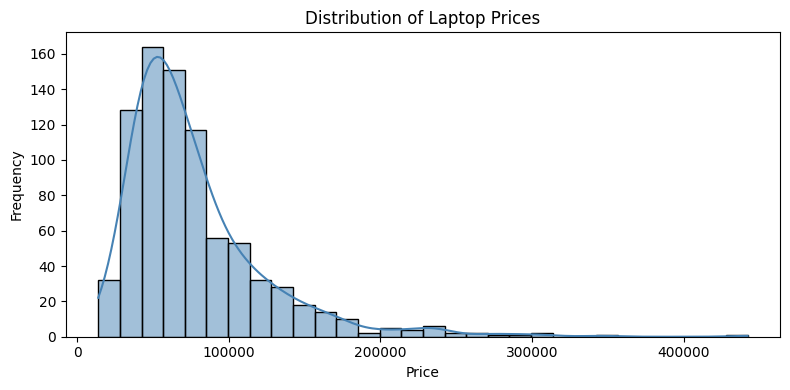

In [50]:
# --- Distribution of Price (Target) ---
plt.figure(figsize=(8, 4))
sns.histplot(df['Price'], kde=True, bins=30, color='steelblue')
plt.title('Distribution of Laptop Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

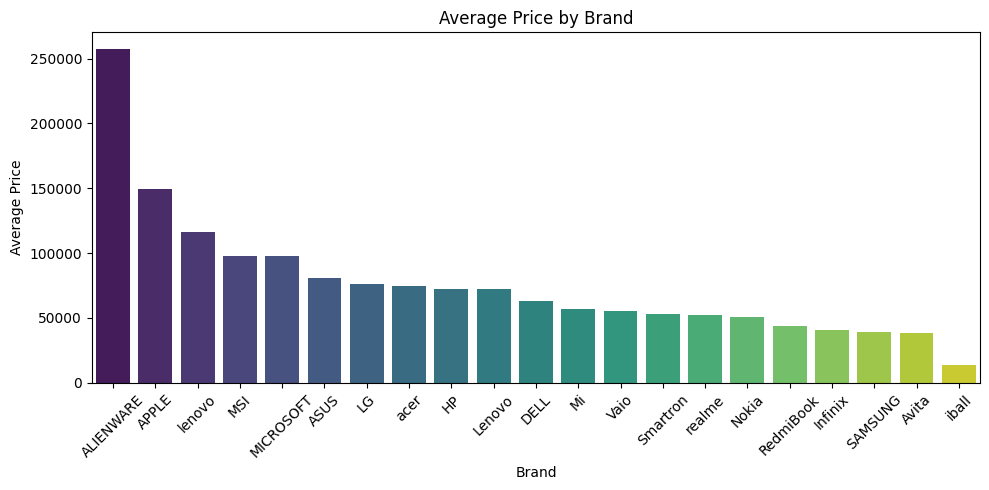

In [51]:
# --- Average Price by Brand ---
plt.figure(figsize=(10, 5))
brand_price = df.groupby('brand')['Price'].mean().sort_values(ascending=False)
sns.barplot(x=brand_price.index, y=brand_price.values, palette='viridis')
plt.title('Average Price by Brand')
plt.xlabel('Brand')
plt.ylabel('Average Price')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

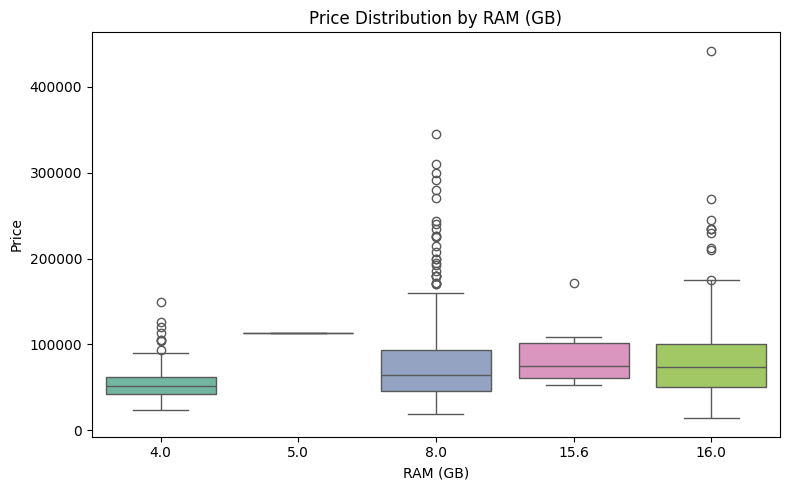

In [52]:
# --- Price vs RAM ---
plt.figure(figsize=(8, 5))
sns.boxplot(x='ram_gb', y='Price', data=df, palette='Set2')
plt.title('Price Distribution by RAM (GB)')
plt.xlabel('RAM (GB)')
plt.ylabel('Price')
plt.tight_layout()
plt.show()

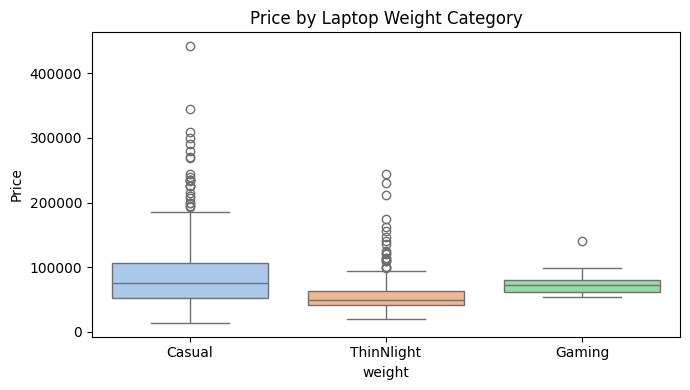

In [53]:
# --- Price by Weight Category ---
plt.figure(figsize=(7, 4))
sns.boxplot(x='weight', y='Price', data=df, palette='pastel')
plt.title('Price by Laptop Weight Category')
plt.tight_layout()
plt.show()

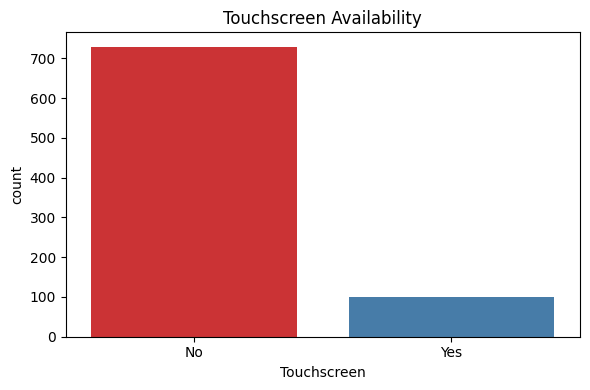

In [54]:
# --- Count of Touchscreen vs Non-Touchscreen ---
plt.figure(figsize=(6, 4))
sns.countplot(x='Touchscreen', data=df, palette='Set1')
plt.title('Touchscreen Availability')
plt.tight_layout()
plt.show()

## 10. Checking Correlation Between Target and Other Columns

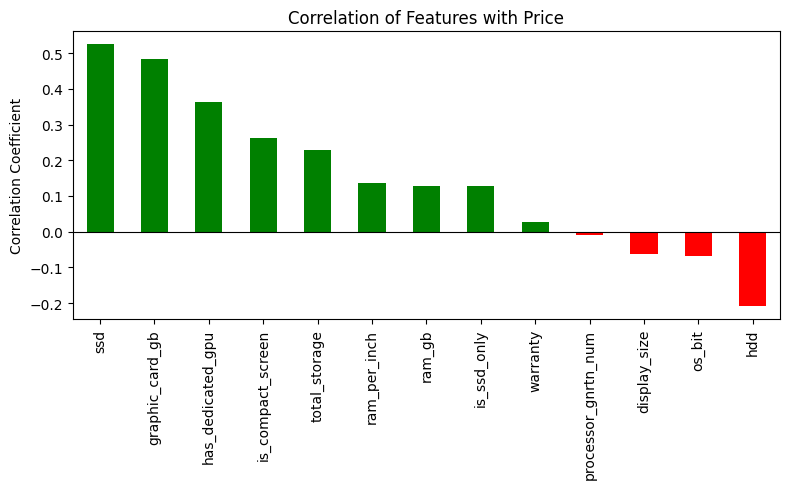

ssd                    0.524241
graphic_card_gb        0.483771
has_dedicated_gpu      0.363071
is_compact_screen      0.262682
total_storage          0.228829
ram_per_inch           0.137602
ram_gb                 0.128109
is_ssd_only            0.127599
warranty               0.026549
processor_gnrtn_num   -0.008083
display_size          -0.063349
os_bit                -0.068420
hdd                   -0.208340
Name: Price, dtype: float64


In [55]:
# Correlation of numeric features with Price
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr_with_price = df[numeric_cols].corr()['Price'].drop('Price').sort_values(ascending=False)

plt.figure(figsize=(8, 5))
corr_with_price.plot(kind='bar', color=['green' if v > 0 else 'red' for v in corr_with_price])
plt.title('Correlation of Features with Price')
plt.ylabel('Correlation Coefficient')
plt.axhline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

print(corr_with_price)

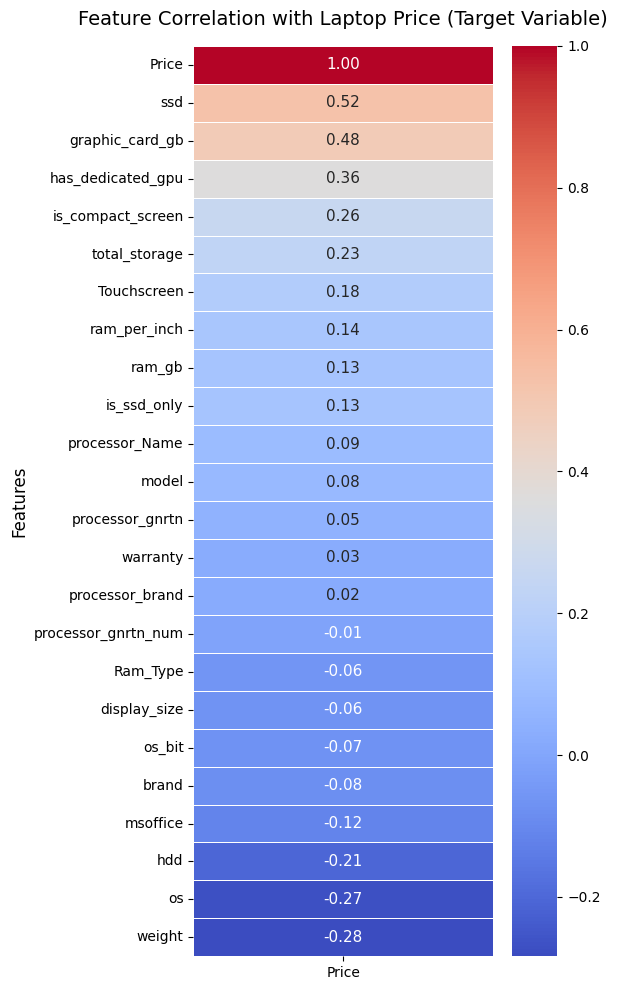

In [56]:
# 1. Create a temporary DataFrame copy so we don't disrupt our original data
plot_df = df.copy()

# 2. Quickly encode text columns to numbers so they show up on the heatmap
le = LabelEncoder()
for col in plot_df.select_dtypes(include=['object', 'string']).columns:
    plot_df[col] = le.fit_transform(plot_df[col].astype(str))

# 3. Isolate the correlation values specifically for 'Price'
# We sort them in descending order so the biggest price drivers sit at the top
price_corr = plot_df.corr()[['Price']].sort_values(by='Price', ascending=False)

# 4. Plot a beautifully styled vertical correlation strip
plt.figure(figsize=(6, 10))
sns.heatmap(
    price_corr, 
    annot=True,             # Shows the exact correlation number
    cmap='coolwarm',        # Red for expensive features, blue for cheap ones
    fmt=".2f",              # Limits the decimal places to 2 digits
    linewidths=0.5,         # Adds clear spaces between the rows
    annot_kws={"size": 11}  # Keeps the font size readable and clean
)

plt.title('Feature Correlation with Laptop Price (Target Variable)', fontsize=14, pad=15)
plt.ylabel('Features', fontsize=12)
plt.tight_layout()
plt.show()

## 11. Features and Target Separation

In [57]:
# Drop columns not useful for prediction
drop_cols = ['processor_gnrtn', 'Price']
X = df.drop(columns=drop_cols)
y = df['Price']

print(f'Features shape: {X.shape}')
print(f'Target shape:   {y.shape}')
print(f'\nFeature columns: {X.columns.tolist()}')

Features shape: (830, 22)
Target shape:   (830,)

Feature columns: ['brand', 'model', 'processor_brand', 'processor_Name', 'ram_gb', 'Ram_Type', 'ssd', 'hdd', 'os', 'os_bit', 'graphic_card_gb', 'weight', 'display_size', 'warranty', 'Touchscreen', 'msoffice', 'processor_gnrtn_num', 'total_storage', 'is_ssd_only', 'ram_per_inch', 'has_dedicated_gpu', 'is_compact_screen']


## 12. Encoding

In [58]:
# Automatically detect ALL text/categorical columns (including model & processor_Name)
categorical_cols = X.select_dtypes(include=['object', 'string', 'category']).columns.tolist()

print(f"\nEncoding the following categorical columns: {categorical_cols}")

# Apply Label Encoding safely to preserve structural market value hierarchies
le = LabelEncoder()
for col in categorical_cols:
    # Convert to string to handle any rogue missing values, then encode
    X[col] = le.fit_transform(X[col].astype(str))

# Confirm what columns are going into Feature Selection and PCA
print(f'\nFinal Feature columns ready for scaling: {X.columns.tolist()}')
X.head()


Encoding the following categorical columns: ['brand', 'model', 'processor_brand', 'processor_Name', 'Ram_Type', 'os', 'weight', 'Touchscreen', 'msoffice']

Final Feature columns ready for scaling: ['brand', 'model', 'processor_brand', 'processor_Name', 'ram_gb', 'Ram_Type', 'ssd', 'hdd', 'os', 'os_bit', 'graphic_card_gb', 'weight', 'display_size', 'warranty', 'Touchscreen', 'msoffice', 'processor_gnrtn_num', 'total_storage', 'is_ssd_only', 'ram_per_inch', 'has_dedicated_gpu', 'is_compact_screen']


,brand,model,processor_brand,processor_Name,ram_gb,Ram_Type,ssd,hdd,os,os_bit,...,display_size,warranty,Touchscreen,msoffice,processor_gnrtn_num,total_storage,is_ssd_only,ram_per_inch,has_dedicated_gpu,is_compact_screen
0,2,23,4,5,4.0,1,0,1024,1,64,...,15.6,1,0,0,10.0,1024,0,0.25641,0,0
1,2,94,4,5,4.0,0,512,0,1,64,...,15.6,1,0,0,10.0,512,1,0.25641,0,0
2,5,28,4,0,4.0,0,512,0,1,64,...,15.6,1,0,1,11.0,512,1,0.25641,0,0
3,5,28,4,0,4.0,0,512,0,1,64,...,15.6,0,0,0,11.0,512,1,0.25641,0,0
4,8,56,4,0,4.0,0,0,1024,1,64,...,15.6,1,0,1,10.0,1024,0,0.25641,0,0


## 13. Feature Selection

In [59]:
# Compute correlation with target
corr_matrix = X.copy()
corr_matrix['Price'] = y.values
feature_corr = corr_matrix.corr()['Price'].drop('Price').abs().sort_values(ascending=False)

print('Feature correlation with Price:')
print(feature_corr)

# Select features with |corr| > 0.05
selected_features = feature_corr[feature_corr > 0.05].index.tolist()
print(f'\nSelected features ({len(selected_features)}): {selected_features}')

X = X[selected_features]

Feature correlation with Price:
ssd                    0.524241
graphic_card_gb        0.483771
has_dedicated_gpu      0.363071
weight                 0.283616
os                     0.271254
is_compact_screen      0.262682
total_storage          0.228829
hdd                    0.208340
Touchscreen            0.176286
ram_per_inch           0.137602
ram_gb                 0.128109
is_ssd_only            0.127599
msoffice               0.116419
processor_Name         0.091225
model                  0.081630
brand                  0.080937
os_bit                 0.068420
display_size           0.063349
Ram_Type               0.060296
warranty               0.026549
processor_brand        0.021406
processor_gnrtn_num    0.008083
Name: Price, dtype: float64

Selected features (19): ['ssd', 'graphic_card_gb', 'has_dedicated_gpu', 'weight', 'os', 'is_compact_screen', 'total_storage', 'hdd', 'Touchscreen', 'ram_per_inch', 'ram_gb', 'is_ssd_only', 'msoffice', 'processor_Name', 'model', 'brand'

## 14. Feature Scaling

In [60]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f'Scaled features shape: {X_scaled.shape}')
print(f'Mean (should be ~0): {X_scaled.mean(axis=0).round(3)}')
print(f'Std  (should be ~1): {X_scaled.std(axis=0).round(3)}')

Scaled features shape: (830, 19)
Mean (should be ~0): [ 0.  0.  0.  0.  0.  0. -0. -0. -0.  0.  0. -0.  0.  0. -0. -0.  0. -0.
  0.]
Std  (should be ~1): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


## 15. PCA (Principal Component Analysis)

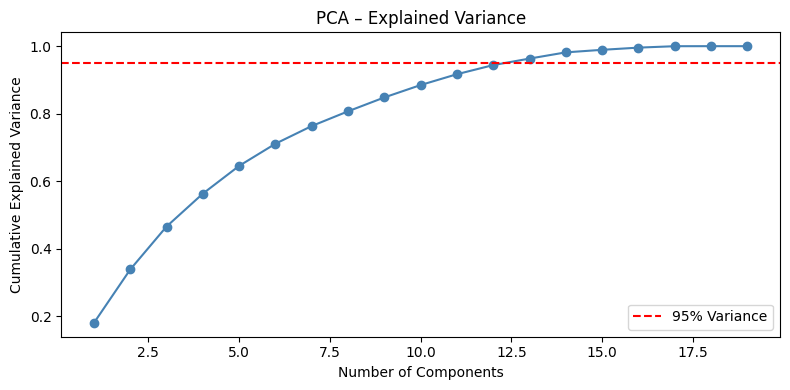

Components needed to explain 95% variance: 13


In [61]:
# Fit PCA to see explained variance
pca_full = PCA()
pca_full.fit(X_scaled)

explained_var = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(8, 4))
plt.plot(range(1, len(explained_var)+1), explained_var, marker='o', color='steelblue')
plt.axhline(0.95, color='red', linestyle='--', label='95% Variance')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA – Explained Variance')
plt.legend()
plt.tight_layout()
plt.show()

# Number of components for 95% variance
n_components = np.argmax(explained_var >= 0.95) + 1
print(f'Components needed to explain 95% variance: {n_components}')

In [62]:
# Apply PCA with selected n_components
pca = PCA(n_components=n_components)
X_pca = pca.fit_transform(X_scaled)

print(f'Shape before PCA: {X_scaled.shape}')
print(f'Shape after  PCA: {X_pca.shape}')

Shape before PCA: (830, 19)
Shape after  PCA: (830, 13)


## 16. Train Test Split

In [63]:
X_train, X_test, y_train, y_test = train_test_split(
    X_pca, y, test_size=0.2, random_state=42
)

print(f'Training set:   {X_train.shape[0]} samples')
print(f'Test set:       {X_test.shape[0]} samples')

Training set:   664 samples
Test set:       166 samples


## 17. Model Preparation

In [64]:
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(max_depth=8, random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=200, max_depth=16, min_samples_split=4, max_features='sqrt', random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=150, learning_rate=0.07, max_depth=6, subsample=0.8, random_state=42)
}

# Train all models
for name, model in models.items():
    model.fit(X_train, y_train)
    print(f'>> {name} trained')

>> Linear Regression trained
>> Decision Tree trained
>> Random Forest trained
>> Gradient Boosting trained


## 18. Model Accuracy

In [65]:
results = []

for name, model in models.items():
    y_pred = model.predict(X_test)
    r2  = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    results.append({'Model': name, 'R² Score': round(r2, 4),
                    'MAE': round(mae, 2), 'RMSE': round(rmse, 2)})

results_df = pd.DataFrame(results).sort_values('R² Score', ascending=False)
print('=== Model Performance on Test Set ===')
results_df

=== Model Performance on Test Set ===


,Model,R² Score,MAE,RMSE
2,Random Forest,0.7006,14392.59,22198.15
3,Gradient Boosting,0.6235,15372.70,24893.20
1,Decision Tree,0.5282,16742.22,27865.84
0,Linear Regression,0.4542,20532.54,29971.09


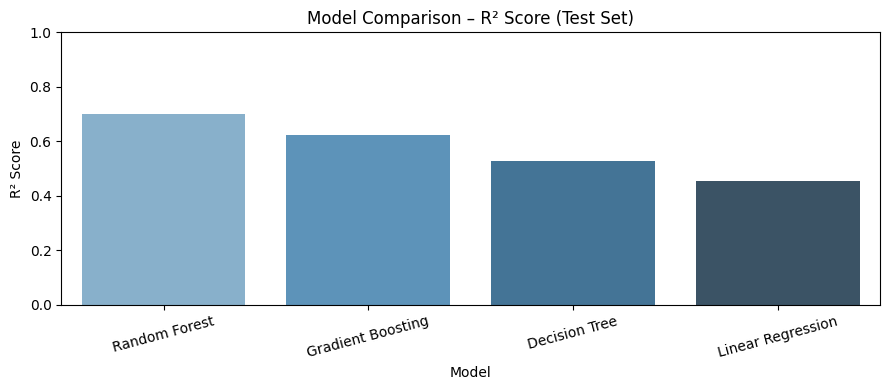

In [66]:
# Visualize R² scores
plt.figure(figsize=(9, 4))
sns.barplot(x='Model', y='R² Score', data=results_df, palette='Blues_d')
plt.title('Model Comparison – R² Score (Test Set)')
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## 19. Cross Validation Function

In [67]:
def cross_val_function(model, X, y, cv=5, scoring='r2'):
    """
    Perform cross-validation and return scores.
    
    Parameters:
        model   : sklearn estimator
        X       : feature array
        y       : target array
        cv      : number of folds (default 5)
        scoring : metric to use  (default 'r2')
    
    Returns:
        scores  : array of CV scores
    """
    scores = cross_val_score(model, X, y, cv=cv, scoring=scoring)
    return scores

print('cross_val_function defined')

cross_val_function defined


## 20. Cross Validation Accuracy

In [68]:
cv_results = []

for name, model in models.items():
    scores = cross_val_function(model, X_pca, y, cv=5, scoring='r2')
    cv_results.append({
        'Model': name,
        'CV Mean R²': round(scores.mean(), 4),
        'CV Std':     round(scores.std(), 4),
        'All Folds':  [round(s, 4) for s in scores]
    })
    print(f'{name}: Mean R² = {scores.mean():.4f} (+/- {scores.std():.4f})')

cv_df = pd.DataFrame(cv_results)[['Model','CV Mean R²','CV Std']].sort_values('CV Mean R²', ascending=False)
print()
print('=== Cross-Validation Summary (5-Fold) ===')
cv_df

Linear Regression: Mean R² = 0.3489 (+/- 0.1522)
Decision Tree: Mean R² = 0.3123 (+/- 0.2699)
Random Forest: Mean R² = 0.3517 (+/- 0.4710)
Gradient Boosting: Mean R² = 0.5190 (+/- 0.0990)

=== Cross-Validation Summary (5-Fold) ===


,Model,CV Mean R²,CV Std
3,Gradient Boosting,0.5190,0.0990
2,Random Forest,0.3517,0.4710
0,Linear Regression,0.3489,0.1522
1,Decision Tree,0.3123,0.2699


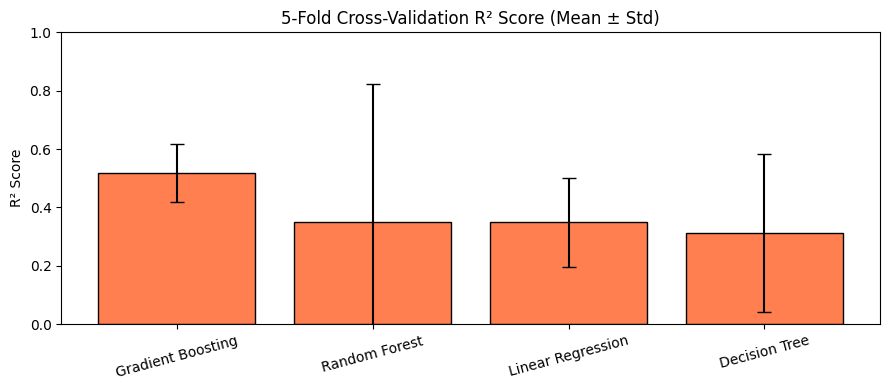

In [69]:
# Visualize CV scores with error bars
plt.figure(figsize=(9, 4))
plt.bar(cv_df['Model'],
        cv_df['CV Mean R²'],
        yerr=cv_df['CV Std'],
        color='coral', edgecolor='black', capsize=5)
plt.title('5-Fold Cross-Validation R² Score (Mean ± Std)')
plt.ylabel('R² Score')
plt.xticks(rotation=15)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

In [70]:
# Final Summary
best_model_name = cv_df.iloc[0]['Model']
best_cv_r2      = cv_df.iloc[0]['CV Mean R²']
print('===============================')
print(f'Best Model     : {best_model_name}')
print(f'Best CV R²     : {best_cv_r2}')
print('===============================')

Best Model     : Gradient Boosting
Best CV R²     : 0.519
